# Validación estadística

Sección separada de la herramienta operativa del pipeline (Snakemake + interfaz web). Analiza, con muestras reales aportadas para este fin, qué tan bien concuerdan las predicciones genotípicas del pipeline con los fenotipos de referencia documentados para cada una.

Estructura de este notebook:

1. [Muestras reales](#Muestras-reales)
2. [Resultados por muestra](#Resultados-por-muestra)
3. [Discusión](#Discusión)

El pipeline ya corrió (en modo solo-ensamblaje, ver `validacion_estadistica/run_validation_batch.py`) sobre las 92 muestras, y `run_taxonomy_check.py` corrió Kraken2 sobre cada ensamblaje para confirmar la especie. `prepare_statistics_input.py` junta la comparación contra el estándar de referencia de cada muestra (`resultados/tables/reference_comparison/`) con CheckM, QUAST, MLST, Kraken2 y la categoría de control, en `resultados/tables/validation_summary.tsv`. Este notebook parte de esa tabla ya agregada; ningún cálculo estadístico se hace en Python, solo aquí en R.

In [1]:
suppressPackageStartupMessages({
  library(readr)
  library(caret)
  library(irr)
  library(ggplot2)
})

base_dir <- ".."
stats_dir <- file.path(base_dir, "resultados/estadisticas")
plots_dir <- file.path(stats_dir, "plots")
dir.create(plots_dir, recursive = TRUE, showWarnings = FALSE)

## Muestras reales

Listado y metadatos de las muestras usadas para la validación estadística (`validacion_estadistica/muestras/`): identificador, accesión, fenotipo de referencia documentado, procedencia.

Conjunto de 92 genomas reales ya ensamblados, descargados de NCBI y **seleccionados como *E. coli*** según los metadatos de origen (la verificación taxonómica de la sección siguiente muestra que esa etiqueta no siempre era correcta). Composición por categoría de control y tipo (positivo/negativo/especial) — ver `validacion_estadistica/README.md` para el detalle de cómo se armó este conjunto y las brechas frente al criterio original de 100 genomas.

In [2]:
samples_metadata <- read_csv(file.path(base_dir, "muestras/muestras_validacion_completo.csv"), show_col_types = FALSE)

cat("Total de muestras:", nrow(samples_metadata), "\n\n")
cat("Categoría x tipo de control:\n")
table(samples_metadata$`Clasificación`, samples_metadata$`Tipo de control`)

Total de muestras: 92 



Categoría x tipo de control:


                
                 Especial Negativo Positivo
  AmpC                  0        0       10
  CONTROL LIMITE        5        0        0
  ESBL                  0        0       47
  NEGATIVO              0       30        0

## Resultados por muestra

Resultados del pipeline para cada muestra de esta sección (`validacion_estadistica/resultados/`): genes detectados, clasificación genotípica, y su comparación contra el fenotipo de referencia.

`confusion_category` es TP/TN/FP/FN cuando la muestra tiene un estándar de referencia evaluable, o "Indeterminado" cuando no lo tiene (los 5 controles límite: su propósito es evaluar robustez del pipeline ante calidad subóptima de ensamblaje, no comparar genotipo). Se muestran primero los 17 casos discordantes (13 FN + 4 FP) uno por uno y luego los 5 indeterminados. La columna `species_check` se incluye ya en la tabla de discordantes porque, como revela la sección siguiente, la mayoría de los falsos negativos no son fallas de detección sino muestras que resultaron no ser *E. coli*.

In [3]:
validation_summary <- read_tsv(file.path(base_dir, "resultados/tables/validation_summary.tsv"), show_col_types = FALSE)

cat("Distribución completa (92 muestras):\n")
table(validation_summary$confusion_category)

Distribución completa (92 muestras):



           FN            FP Indeterminado            TN            TP 
           13             4             5            26            44 

In [4]:
discordant_cases <- subset(
  validation_summary,
  confusion_category %in% c("FN", "FP"),
  select = c(sample_id, category, expected_gene, detected_gene, confusion_category, species_check, predominant_taxon, assembly_status)
)
discordant_cases

sample_id,category,expected_gene,detected_gene,confusion_category,species_check,predominant_taxon,assembly_status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCA_018185615_1,ESBL,blaCTX-M-15,none,FN,otra_especie,Listeria monocytogenes,FAIL
GCA_019047325_1,ESBL,blaCTX-M-3,none,FN,otra_especie,Aeromonas sp. FDAARGOS 1403,PASS
GCA_036492125_1,ESBL,blaCTX-M-2,none,FN,otra_especie,Listeria seeligeri,FAIL
GCA_028391205_1,ESBL,blaCTX-M-14b,none,FN,otra_especie,Staphylococcus aureus,FAIL
GCA_017392015_1,ESBL,blaCTX-M-8,none,FN,otra_especie,Hoskinsella hominis,FAIL
GCA_023195715_1,ESBL,blaSHV-12,none,FN,otra_especie,Enterobacter roggenkampii,PASS
GCA_024368115_1,ESBL,blaTEM-10,none,FN,confirmada,Escherichia coli,PASS
GCA_021431105_1,ESBL,blaSHV-2,none,FN,otra_especie,Salmonella enterica,PASS
GCA_022819305_1,ESBL,blaSHV-18,none,FN,otra_especie,Gordonia amicalis,PASS


In [5]:
indeterminate_cases <- subset(
  validation_summary,
  confusion_category == "Indeterminado",
  select = c(sample_id, category, known_result, detected_gene, completeness_status, assembly_status)
)
indeterminate_cases

sample_id,category,known_result,detected_gene,completeness_status,assembly_status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCA_000221905_2,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)","blaCTX-M, blaTEM-1, cirA_I160SfsTer34, ompF_Q88PfsTer2",FAIL,FAIL
GCF_000263895_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS
GCF_000734955_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS
GCF_000285655_3,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)","blaCMY-23, blaCTX-M-15, blaOXA-1, blaTEM-1",PASS,PASS
GCF_000234295_1,CONTROL LIMITE,"No aplica (control límite por calidad de ensamblaje, no por genotipo)",none,PASS,PASS


### Verificación taxonómica (Kraken2)

Al revisar los 13 falsos negativos anteriores caso por caso, varios mostraban %GC muy alejado del rango normal de *E. coli* (~50–51%) y MLST sin ningún alelo resuelto (0 de 7 loci) — un indicio fuerte de que el genoma no es realmente *E. coli*, más que de una falla de detección de AMRFinderPlus. `run_taxonomy_check.py` corrió Kraken2 directamente sobre cada ensamblaje (mismo criterio que la regla `kraken2` de la sección operativa, pero sobre contigs en vez de lecturas) para confirmarlo con una herramienta de identificación taxonómica real.

`species_check` clasifica cada muestra según su taxón predominante: `confirmada` si es *Escherichia coli*, `shigella_revision_manual` si es *Shigella* (pariente genómico tan cercano que el pipeline nunca lo auto-excluye, ver `parse_kraken2.py`), u `otra_especie` en cualquier otro caso.

In [6]:
table(validation_summary$species_check)


              confirmada             otra_especie shigella_revision_manual 
                      77                       14                        1 

In [7]:
other_species_cases <- subset(
  validation_summary,
  species_check == "otra_especie",
  select = c(sample_id, category, confusion_category, predominant_taxon, ecoli_percentage, other_contaminant_percentage)
)
other_species_cases

sample_id,category,confusion_category,predominant_taxon,ecoli_percentage,other_contaminant_percentage
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
GCA_018185615_1,ESBL,FN,Listeria monocytogenes,0.00,85.71
GCA_019047325_1,ESBL,FN,Aeromonas sp. FDAARGOS 1403,0.00,100.00
GCA_036492125_1,ESBL,FN,Listeria seeligeri,0.00,100.00
GCA_028391205_1,ESBL,FN,Staphylococcus aureus,0.00,86.25
GCA_017392015_1,ESBL,FN,Hoskinsella hominis,0.00,24.31
GCA_023195715_1,ESBL,FN,Enterobacter roggenkampii,0.00,74.99
GCA_021431105_1,ESBL,FN,Salmonella enterica,2.81,74.16
GCA_022819305_1,ESBL,FN,Gordonia amicalis,0.00,100.00
GCA_023819205_1,ESBL,FN,Homo sapiens,0.00,19.21


**14 de las 92 muestras (15.2%) no son realmente *E. coli*** según Kraken2 — apareció de todo, desde parientes cercanos de Enterobacteriaceae (*Klebsiella*, *Enterobacter*, *Citrobacter*, *Salmonella*) hasta especies completamente ajenas (*Listeria*, *Staphylococcus aureus*, *Aeromonas*) y hasta una muestra predominantemente *Homo sapiens*. De ellas, 11 habían quedado clasificadas como falsos negativos y 3 como verdaderos positivos (`GCF_003176195_1`, `GCF_003175335_1`: *Klebsiella*; `GCA_026719305_1`: *Citrobacter braakii* — parientes que también portan genes ESBL/AmpC plasmídicos, por lo que el gen sí se detectó aunque el genoma no sea *E. coli*). Ninguna de las 14 pertenece a la categoría NEGATIVO ni a CONTROL LIMITE.

Esto no se detectó antes porque esta sección no corre verificación taxonómica de forma rutinaria (a diferencia de la sección operativa, que sí la exige vía Kraken2 sobre lecturas antes de reportar AMR). La causa más probable es la ya documentada en `validacion_estadistica/muestras/README.md`: escasez del pool de genomas de *E. coli* con blaSHV/blaTEM/AmpC plasmídica ya ensamblados en NCBI, que forzó sustituciones cuyo organismo de origen no siempre se verificó de forma independiente. La sección de Discusión recalcula sensibilidad/especificidad/kappa excluyendo estas 14 muestras.

## Discusión

Interpretación conjunta de los resultados de todas las muestras de esta sección: métricas de concordancia, casos discordantes y su posible explicación, limitaciones observadas.

Las 5 muestras "Indeterminado" (controles límite, sin estándar de referencia evaluable por genotipo) se excluyen siempre. Además, esta sección compara dos cálculos: sobre las 87 muestras con referencia evaluable (`evaluable_all`, sin filtrar por especie, igual que en la primera versión de este análisis) y sobre las 73 que además tienen a *Escherichia coli* como taxón predominante confirmado por Kraken2 (`evaluable_confirmed`, excluye las 14 `otra_especie`, mantiene la de `shigella_revision_manual` por la política ya explicada).

In [8]:
evaluable_all <- subset(validation_summary, confusion_category != "Indeterminado")
evaluable_all$reference_status <- factor(evaluable_all$reference_status, levels = c("negative", "positive"))
evaluable_all$pipeline_status <- factor(evaluable_all$pipeline_status, levels = c("negative", "positive"))
confusion_all <- confusionMatrix(evaluable_all$pipeline_status, evaluable_all$reference_status, positive = "positive")

evaluable_confirmed <- subset(validation_summary, confusion_category != "Indeterminado" & species_check != "otra_especie")
evaluable_confirmed$reference_status <- factor(evaluable_confirmed$reference_status, levels = c("negative", "positive"))
evaluable_confirmed$pipeline_status <- factor(evaluable_confirmed$pipeline_status, levels = c("negative", "positive"))
confusion_confirmed <- confusionMatrix(evaluable_confirmed$pipeline_status, evaluable_confirmed$reference_status, positive = "positive")
capture.output(confusion_confirmed, file = file.path(stats_dir, "confusion_matrix.txt"))

confusion_confirmed

Confusion Matrix and Statistics

          Reference
Prediction negative positive
  negative       26        2
  positive        4       41
                                          
               Accuracy : 0.9178          
                 95% CI : (0.8296, 0.9692)
    No Information Rate : 0.589           
    P-Value [Acc > NIR] : 3.722e-10       
                                          
                  Kappa : 0.8285          
                                          
 Mcnemar's Test P-Value : 0.6831          
                                          
            Sensitivity : 0.9535          
            Specificity : 0.8667          
         Pos Pred Value : 0.9111          
         Neg Pred Value : 0.9286          
             Prevalence : 0.5890          
         Detection Rate : 0.5616          
   Detection Prevalence : 0.6164          
      Balanced Accuracy : 0.9101          
                                          
       'Positive' Class : positive        


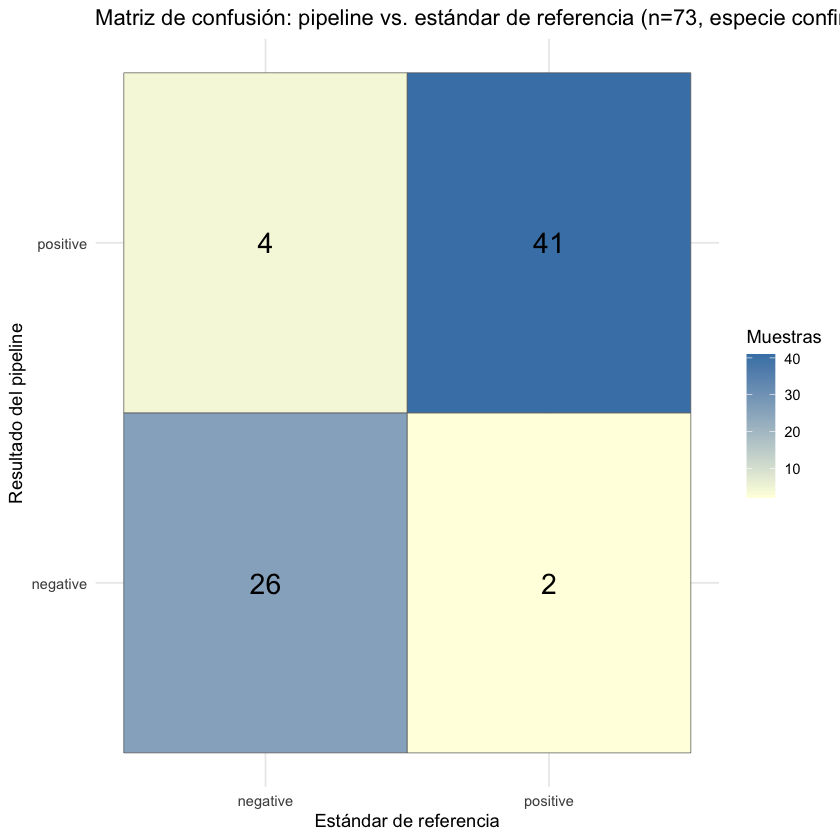

In [9]:
contingency_table <- as.data.frame(confusion_confirmed$table)
colnames(contingency_table) <- c("pipeline_status", "reference_status", "count")
write_csv(contingency_table, file.path(stats_dir, "contingency_table.csv"))

confusion_matrix_plot <- ggplot(contingency_table, aes(x = reference_status, y = pipeline_status, fill = count)) +
  geom_tile(color = "grey40") +
  geom_text(aes(label = count), color = "black", size = 6) +
  scale_fill_gradient(low = "lightyellow", high = "steelblue") +
  labs(title = "Matriz de confusión: pipeline vs. estándar de referencia (n=73, especie confirmada)", x = "Estándar de referencia", y = "Resultado del pipeline", fill = "Muestras") +
  theme_minimal()
ggsave(file.path(plots_dir, "confusion_matrix_heatmap.png"), confusion_matrix_plot, width = 6, height = 5)
confusion_matrix_plot

Sensibilidad y especificidad con su intervalo de confianza del 95% (Clopper-Pearson vía `binom.test`), igual criterio que `workflow/scripts/run_statistics.R` en la sección operativa del pipeline: `confusionMatrix` de `caret` ya calcula un IC del 95% para la exactitud global, pero no por separado para sensibilidad y especificidad. Se calcula para ambos conjuntos (todas / especie confirmada), lado a lado.

In [10]:
compute_rate_with_ci <- function(successes, total) {
  if (total == 0) return(list(estimate = NA_real_, ci_lower = NA_real_, ci_upper = NA_real_))
  test_result <- binom.test(successes, total)
  list(estimate = unname(test_result$estimate), ci_lower = test_result$conf.int[1], ci_upper = test_result$conf.int[2])
}

build_classification_metrics <- function(confusion_result, n_total) {
  confusion_counts <- confusion_result$table
  true_positive_count <- confusion_counts["positive", "positive"]
  false_negative_count <- confusion_counts["negative", "positive"]
  true_negative_count <- confusion_counts["negative", "negative"]
  false_positive_count <- confusion_counts["positive", "negative"]

  sensitivity_stats <- compute_rate_with_ci(true_positive_count, true_positive_count + false_negative_count)
  specificity_stats <- compute_rate_with_ci(true_negative_count, true_negative_count + false_positive_count)
  accuracy_overall <- confusion_result$overall

  data.frame(
    metric = c("Sensitivity", "Specificity", "Accuracy"),
    estimate = c(sensitivity_stats$estimate, specificity_stats$estimate, unname(accuracy_overall["Accuracy"])),
    ci_lower = c(sensitivity_stats$ci_lower, specificity_stats$ci_lower, unname(accuracy_overall["AccuracyLower"])),
    ci_upper = c(sensitivity_stats$ci_upper, specificity_stats$ci_upper, unname(accuracy_overall["AccuracyUpper"])),
    n = c(true_positive_count + false_negative_count, true_negative_count + false_positive_count, n_total)
  )
}

classification_metrics_all <- build_classification_metrics(confusion_all, nrow(evaluable_all))
classification_metrics_confirmed <- build_classification_metrics(confusion_confirmed, nrow(evaluable_confirmed))

# Se guardan ambos conjuntos como artefactos auditables: el principal
# (especie confirmada, n=73) y el de todas las muestras evaluables (n=87,
# sin filtrar por especie) para dejar trazable el efecto de la exclusion.
write_csv(classification_metrics_confirmed, file.path(stats_dir, "classification_metrics.csv"))
write_csv(classification_metrics_all, file.path(stats_dir, "classification_metrics_all_samples.csv"))

cat("Todas las muestras (n=", nrow(evaluable_all), "):\n", sep = "")
print(classification_metrics_all)
cat("\nEspecie confirmada (n=", nrow(evaluable_confirmed), "):\n", sep = "")
print(classification_metrics_confirmed)

Todas las muestras (n=87):


       metric  estimate  ci_lower  ci_upper  n
1 Sensitivity 0.7719298 0.6416366 0.8726029 57
2 Specificity 0.8666667 0.6927816 0.9624465 30
3    Accuracy 0.8045977 0.7056802 0.8818513 87



Especie confirmada (n=73):


       metric  estimate  ci_lower  ci_upper  n
1 Sensitivity 0.9534884 0.8418885 0.9943167 43
2 Specificity 0.8666667 0.6927816 0.9624465 30
3    Accuracy 0.9178082 0.8296389 0.9692385 73


Índice kappa de Cohen: concordancia entre el estándar de referencia y el resultado del pipeline, corrigiendo por el acuerdo esperado al azar. Sobre el conjunto de especie confirmada.

In [11]:
kappa_result <- kappa2(data.frame(evaluable_confirmed$reference_status, evaluable_confirmed$pipeline_status))
kappa_summary <- data.frame(
  kappa_value = kappa_result$value,
  z_statistic = kappa_result$statistic,
  p_value = kappa_result$p.value,
  n_samples = kappa_result$subjects
)
write_csv(kappa_summary, file.path(stats_dir, "kappa.csv"))
kappa_summary

kappa_value,z_statistic,p_value,n_samples
<dbl>,<dbl>,<dbl>,<int>
0.8285043,7.090339,1.337819e-12,73


In [12]:
category_breakdown <- as.data.frame.matrix(table(
  subset(validation_summary, species_check != "otra_especie")$category,
  subset(validation_summary, species_check != "otra_especie")$confusion_category
))
write_csv(cbind(category = rownames(category_breakdown), category_breakdown), file.path(stats_dir, "category_breakdown.csv"))
category_breakdown

,FN,FP,Indeterminado,TN,TP
,<int>,<int>,<int>,<int>,<int>
AmpC,0,0,0,0,7
CONTROL LIMITE,0,0,5,0,0
ESBL,2,0,0,0,34
NEGATIVO,0,4,0,26,0


### Reproducibilidad computacional

`run_reproducibility_check.py` ejecutó tres veces cada una de las 5 muestras marcadas como control de reproducibilidad, midiendo el tiempo de ejecución y la RAM máxima por corrida (misma metodología que `workflow/scripts/run_with_timing.py`: `resource.getrusage`, un proceso independiente por réplica). El coeficiente de variación —desviación estándar sobre media, en porcentaje— resume la estabilidad entre corridas de una misma muestra. El CV es exclusivo de R en este pipeline; Python solo prepara los tiempos y consumos crudos por corrida.

In [13]:
reproducibility_runs <- read_tsv(file.path(base_dir, "resultados/tables/reproducibility_runs.tsv"), show_col_types = FALSE)

coefficient_of_variation <- function(x) 100 * sd(x) / mean(x)

cv_by_sample <- aggregate(
  cbind(elapsed_seconds, max_ram_gb) ~ sample_id,
  data = reproducibility_runs,
  FUN = function(x) c(mean = mean(x), cv = coefficient_of_variation(x))
)
cv_table <- data.frame(
  sample_id = cv_by_sample$sample_id,
  media_tiempo_s = round(cv_by_sample$elapsed_seconds[, "mean"], 1),
  cv_tiempo_pct = round(cv_by_sample$elapsed_seconds[, "cv"], 2),
  media_ram_gb = round(cv_by_sample$max_ram_gb[, "mean"], 2),
  cv_ram_pct = round(cv_by_sample$max_ram_gb[, "cv"], 2)
)
write_csv(cv_table, file.path(stats_dir, "cv_reproducibilidad.csv"))
cv_table

sample_id,media_tiempo_s,cv_tiempo_pct,media_ram_gb,cv_ram_pct
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
GCA_013010035_1,749.1,4.43,11.08,4.59
GCA_023195715_1,798.9,4.81,11.64,5.47
GCA_059498405_1,766.2,5.49,11.08,11.96
GCF_000026305_1,860.5,4.55,10.06,13.60
GCF_000234295_1,752.5,0.56,10.28,18.53


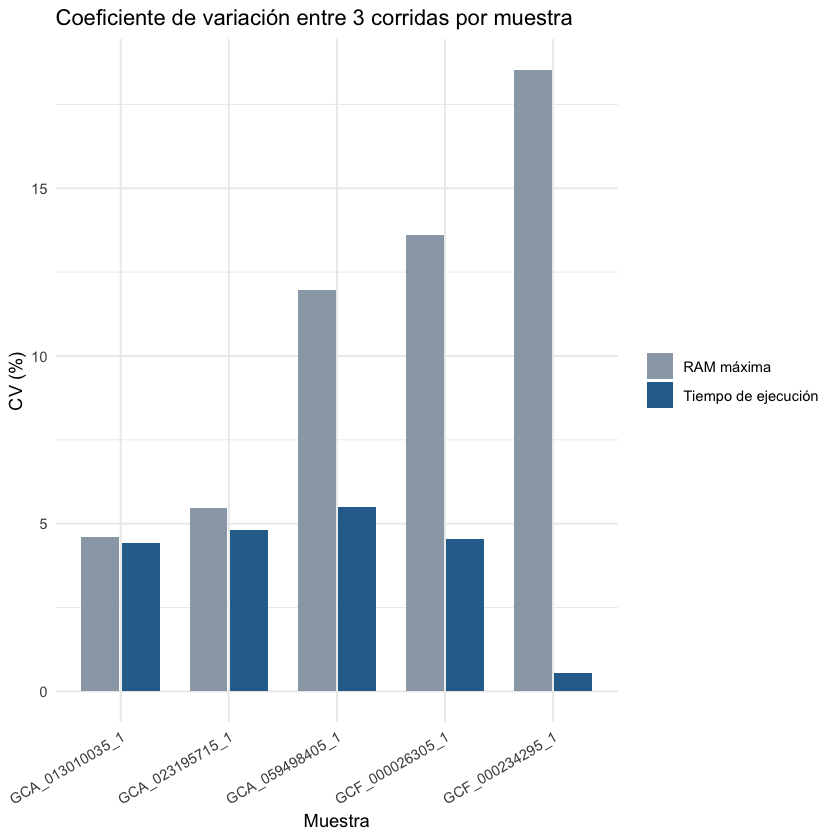

In [14]:
cv_long <- data.frame(
  sample_id = rep(cv_table$sample_id, 2),
  metric = rep(c("Tiempo de ejecución", "RAM máxima"), each = nrow(cv_table)),
  cv = c(cv_table$cv_tiempo_pct, cv_table$cv_ram_pct)
)
cv_plot <- ggplot(cv_long, aes(x = sample_id, y = cv, fill = metric)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.7) +
  scale_fill_manual(values = c("Tiempo de ejecución" = "#2c6e9c", "RAM máxima" = "#9aa7b4")) +
  labs(title = "Coeficiente de variación entre 3 corridas por muestra",
       x = "Muestra", y = "CV (%)", fill = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))
ggsave(file.path(plots_dir, "cv_reproducibilidad.png"), cv_plot, width = 7, height = 4.5)
cv_plot

### Interpretación

**El hallazgo principal de esta validación fue metodológico, no del pipeline**: 14 de las 92 muestras (15.2%) resultaron no ser realmente *E. coli* al verificarlas con Kraken2 (ver sección anterior), y eso explica la mayoría de los falsos negativos que aparecían al mirar las 92 muestras sin filtrar. Excluyendo esas 14, sobre las **73 muestras con especie confirmada y estándar de referencia evaluable**: **sensibilidad 95.3%** (IC 95%: 84.2%–99.4%, n=43 positivos), **especificidad 86.7%** (IC 95%: 69.3%–96.2%, n=30 negativos, sin cambio — ningún falso positivo pertenecía a las 14 excluidas), **exactitud 91.8%** (IC 95%: 83.0%–96.9%). **Kappa = 0.829** (p = 1.3×10⁻¹²): concordancia "casi perfecta" según la escala de Landis y Koch, muy por encima del 0.596 (concordancia moderada-sustancial) que salía al no filtrar por especie.

Para comparar: sobre las 87 muestras sin filtrar por especie, sensibilidad 77.2%, especificidad 86.7%, exactitud 80.5%, kappa 0.596 — los números que había en la primera versión de este notebook, antes de correr la verificación taxonómica.

**2 falsos negativos genuinos quedan** tras excluir las muestras de otra especie (`GCA_024368115_1`, blaTEM-10, MLST ST11; y `GCA_025819395_1`, blaCTX-M-32, MLST ST127 — ambas confirmadas *E. coli* por Kraken2 y con secuencia tipo resuelta en el esquema de Achtman). En ambas, AMRFinderPlus no encontró ningún hit para el gen esperado ni siquiera antes del umbral de identidad/cobertura, con ensamblaje y completitud normales (`PASS`/`PASS`) — sin explicación técnica evidente desde estas métricas. Con solo 2 casos no alcanza para generalizar una causa; queda como observación puntual para revisar manualmente (por ejemplo, verificar en NCBI si la anotación original de esa accesión realmente reporta el gen, o si la versión de la base de datos de AMRFinderPlus usada en este proyecto tiene una brecha para esa variante específica).

**4 falsos positivos**, todos en la categoría NEGATIVO y todos con especie confirmada como *E. coli*: 2 son `blaTEM-1` (beta-lactamasa de espectro estrecho, no ESBL ni AmpC) y 2 son mutaciones puntuales en `cirA` (gen de receptor de membrana, catalogado por AMRFinderPlus como BETA-LACTAM pero no como un gen de resistencia adquirida a cefalosporinas de tercera generación). El estándar de referencia de estas muestras ("ausencia de ESBL adquirida y AmpC plasmídica") es más estrecho que la regla de comparación genotípica de este pipeline (`compare_to_reference.py`), que marca como inesperada *cualquier* beta-lactamasa de la clase BETA-LACTAM detectada en una muestra negativa. `blaTEM-1` en particular es común de forma incidental en *E. coli* y no confiere por sí solo resistencia a cefalosporinas de tercera generación. Es un desajuste de alcance entre la definición del control negativo y la regla de comparación, no una falla de detección del pipeline.

**Los 5 controles límite (Indeterminado) se comportaron como se esperaba** al revisarlos accesión por accesión: la cepa del brote alemán 2011 (O104:H4 TY-2482, `GCA_000221905_2`), con el ensamblaje más fragmentado del conjunto (N50 ≈ 3.9 kb), aún detectó blaCTX-M y blaTEM-1 aunque sin resolver el alelo exacto ni el MLST — degradación elegante; la cepa de referencia EC958 (`GCF_000285655_3`), con ensamblaje completo, detectó los cuatro genes esperados de la literatura (blaCTX-M-15, blaCMY-23, blaOXA-1, blaTEM-1). Los tres restantes (la cepa tipo ATCC 11775 y dos aislados STEC del FDA) dieron "none" en genes adquiridos, coherente con dos motores independientes (AMRFinderPlus y ABricate/ResFinder ambos en cero; los 42–43 hits de ABricate/CARD son el resistoma intrínseco cromosómico, no cefalosporinasas adquiridas). Ninguno es una falla de detección.

**Corrección aplicada al esquema MLST (derivada de esta revisión):** al investigar por qué EC958 —arquetipo mundial del clon ST131— aparecía como ST43, se detectó que el pipeline corría el esquema de **Pasteur** (`ecoli`, 8 loci con `uidA`/`dinB`), no el de **Achtman** (7 loci: `adk, fumC, gyrB, icd, mdh, purA, recA`), que es el estándar de la literatura de *E. coli* (EnteroBase, tipificación de ST131). Se corrigió `config/config.yaml` para usar `ecoli_achtman_4` y se retipificaron las 92 muestras: EC958 pasa a ST131 (correcto), y de paso se resolvió el ST de más muestras (76 vs. 56 con Pasteur). Esto no afecta la detección de AMR ni las métricas de arriba (el MLST es solo contexto epidemiológico), pero ahora los ST reportados sí son comparables con la literatura.

**Limitación metodológica identificada y corregida en esta versión:** la verificación taxonómica (Kraken2) no formaba parte del flujo original de esta sección (a diferencia de la sección operativa, que sí la exige antes de reportar AMR). `run_taxonomy_check.py` la agrega retroactivamente sobre las 92 muestras ya ensambladas. Recomendación para futuras ampliaciones de este conjunto de validación: correr la verificación taxonómica *antes* de dar por buena una muestra nueva, no después.

**Reproducibilidad computacional:** las cinco muestras de control se ejecutaron tres veces cada una. El tiempo de ejecución se mantuvo estable —CV promedio de 4.0%, máximo de 5.5%—, mientras que la RAM máxima varió más, con un CV promedio de 10.8% que llegó a 18.5% en una muestra. La diferencia era previsible: el pico de memoria proviene de la colocación filogenética de CheckM, sensible a la presión de memoria del sistema en cada corrida y a la carga concurrente del equipo. El tiempo de cómputo del pipeline es, por tanto, reproducible; el consumo de memoria pico admite una fluctuación moderada según las condiciones de ejecución.